In [1]:
from sklearn.preprocessing import StandardScaler



import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from tqdm.notebook import tqdm

from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Параметры для воспроизводимости кода

In [2]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


# Чтение данных

In [3]:
df = pd.read_csv('cybersequrity.csv')
df.head()

,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0


### small EDA

In [4]:
df.columns

Index(['svcscan.fs_drivers', 'callbacks.ngeneric',
       'psxview.not_in_eprocess_pool_false_avg',
       'psxview.not_in_eprocess_pool', 'callbacks.nanonymous',
       'psxview.not_in_session', 'psxview.not_in_pslist',
       'psxview.not_in_pspcid_list', 'psxview.not_in_ethread_pool',
       'psxview.not_in_csrss_handles', 'psxview.not_in_pslist_false_avg',
       'psxview.not_in_pspcid_list_false_avg', 'psxview.not_in_deskthrd',
       'psxview.not_in_ethread_pool_false_avg',
       'psxview.not_in_session_false_avg', 'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   svcscan.fs_drivers                      10000 non-null  int64  
 1   callbacks.ngeneric                      10000 non-null  int64  
 2   psxview.not_in_eprocess_pool_false_avg  10000 non-null  float64
 3   psxview.not_in_eprocess_pool            10000 non-null  int64  
 4   callbacks.nanonymous                    10000 non-null  int64  
 5   psxview.not_in_session                  10000 non-null  int64  
 6   psxview.not_in_pslist                   10000 non-null  int64  
 7   psxview.not_in_pspcid_list              10000 non-null  int64  
 8   psxview.not_in_ethread_pool             10000 non-null  int64  
 9   psxview.not_in_csrss_handles            10000 non-null  int64  
 10  psxview.not_in_pslist_false_avg         10000 non-null  flo

### Разбивка на `train`, `test`, `val`.



In [6]:
X, y = df.drop('Class', axis=1), df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

X_train.shape, X_val.shape, X_test.shape

((6000, 15), (2000, 15), (2000, 15))

### Проверка, что класссы разбились в одинаковой пропорции

In [7]:
pd.concat([df['Class'].value_counts(normalize=True).rename('Total'),
          y_train.value_counts(normalize=True).rename('Train'),
          y_val.value_counts(normalize=True).rename('Val'),
          y_test.value_counts(normalize=True).rename('Test')],
          axis=1)

,Total,Train,Val,Test
Class,,,,
1,0.5096,0.509667,0.5095,0.5095
0,0.4904,0.490333,0.4905,0.4905


# Обработка данных

### Стандартизация входных признаков

In [8]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

### Класс для работы с датасетом

In [9]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(X.values)
        self.y = torch.from_numpy(y.values).reshape(-1, 1).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, index):
        return (self.X[index], self.y[index])

In [10]:
train_dataset = CustomDataset(X_train, y_train)
val_dataset = CustomDataset(X_val, y_val)
test_dataset = CustomDataset(X_test, y_test)

### DataLoader'ы для обучения модели батчами. Размер батча выбран 64, так как при меньшем размере модель скорее всего будет недобучаться и медлее сходиться.

In [11]:
BATCH_SIZE = 64

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Первая модель

In [12]:
class MyTorchModel(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU):
        super(MyTorchModel, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred


# train-loop

In [13]:
def train_model(model, num_epochs=100, eval_freq=10):
  train_loss_history, eval_loss_history = [], []
  train_f1_history, eval_f1_history = [], []
  global_step = 0

  model.train()
  for epoch in tqdm(range(num_epochs)):
      for batch_X, target in train_dataloader:
        optimizer.zero_grad()
        log_probs = model(batch_X.to(device))
        loss = loss_function(log_probs, target.to(device))
        loss.backward()
        optimizer.step()

        preds = (log_probs >= 0.5).int().cpu()
        f1 = f1_score(preds, target.cpu().numpy())

        train_loss_history.append((global_step, loss.item()))
        # train_f1_history.append((global_step, f1.item()))
        train_f1_history.append((global_step, f1))

        if global_step % eval_freq == 0:
              val_loss, val_f1 = evaluate(model)
              eval_loss_history.append((global_step, val_loss))
              eval_f1_history.append((global_step, val_f1))

              model.train()

        if global_step % 250 == 0:
              clear_output(True)

              plt.figure(figsize=(15, 5))

              plt.subplot(121)
              plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
              if len(eval_loss_history):
                  plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
              plt.legend()

              plt.subplot(122)
              plt.plot(*zip(*train_f1_history), alpha=0.5, label='train_f1')
              if len(eval_f1_history):
                  plt.plot(*zip(*eval_f1_history), color='red', label='eval_f1')
              plt.legend()
              plt.show()
        global_step += 1

  return model

# eval-loop

In [14]:
@torch.no_grad()
def evaluate(model, data_loader=val_dataloader):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    loss_epoch = 0.
    num_epoch = 0.
    preds_list = []
    targets_list = []

    for batch_X, target in data_loader:
      log_probs = model(batch_X.to(device))
      loss = loss_function(log_probs, target.to(device))
      num = log_probs.shape[0]
      loss_epoch += loss.item() * num
      num_epoch += num

      preds_list += (log_probs >= 0.5).int().cpu().tolist()
      targets_list += target.cpu().numpy().tolist()

    f1 = f1_score(preds_list, targets_list)

    return loss_epoch / num_epoch, f1

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [16]:
model = MyTorchModel(1, 15, 15, 2, nn.ReLU)
model.to(device)

MyTorchModel(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=15, bias=True)
    (1): ReLU()
    (2): Linear(in_features=15, out_features=15, bias=True)
    (3): ReLU()
    (4): Linear(in_features=15, out_features=1, bias=True)
  )
)

В качестве loss-функции выбрана BCELoss(по заданию). В качестве оптимизатора для начала выбран Adam, так как является одним из самых лучших. Для начала возьмем 100 эпох обучения.

In [17]:
loss_function = nn.BCELoss()
# optimizer = optim.SGD(model.parameters(), lr=0.01)
optimizer = optim.Adam(model.parameters(), lr=0.01)

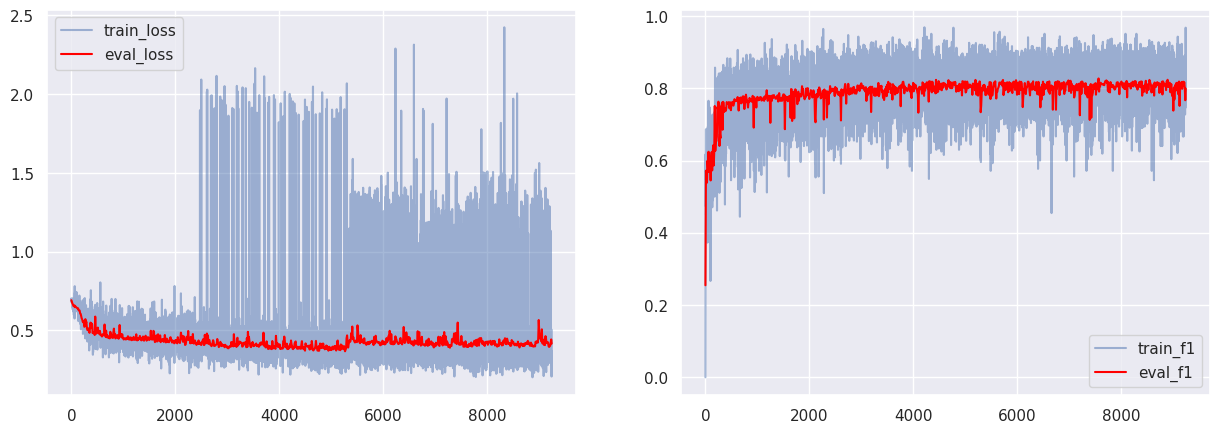

In [18]:
model = train_model(model, num_epochs=100)

In [19]:
evaluate(model, data_loader=test_dataloader)

(0.43510501766204834, 0.8192651439920556)

Заменим функцию активацию на LeakyRelu и сравним результаты. set_seed(42) задается перед каждой новой инициализации модели, для того чтобы достичь воспроизводимости, без результат обучения будет другой, даже если запустить ту же самую ячейку.

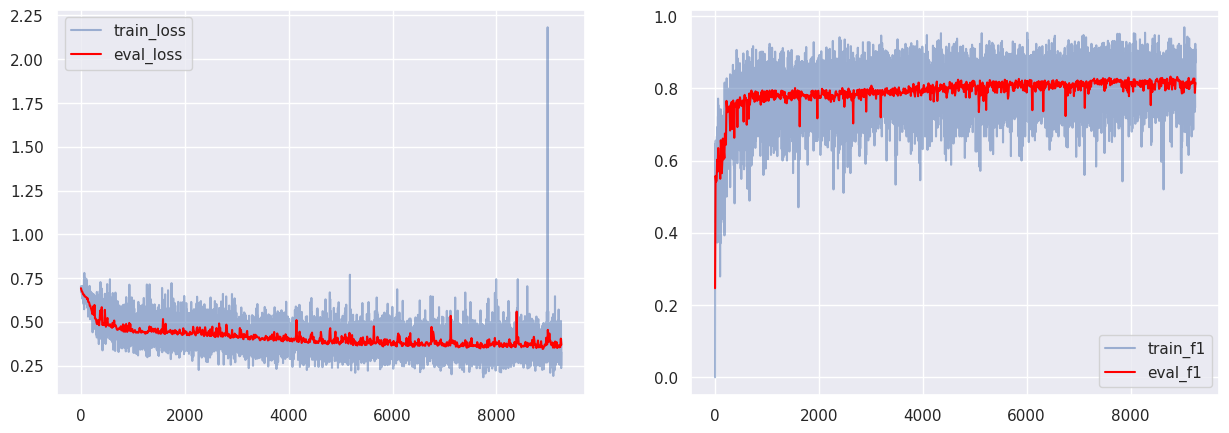

(0.38539210534095764, 0.8094047023511756)

In [20]:
set_seed(42)
model = MyTorchModel(1, 15, 15, 2, nn.LeakyReLU)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Оставим LeakyRelu, так как loss уменьшился, а f1-score не сильно упал.
LeakyReLU предотвращает проблему мёртвых нейронов, характерную для обычного ReLU, и работает лучше Sigmoid/Tanh, которые склонны к затуханию градиента на глубоких сетях.

# Попробуем добавить ещё один линейный слой

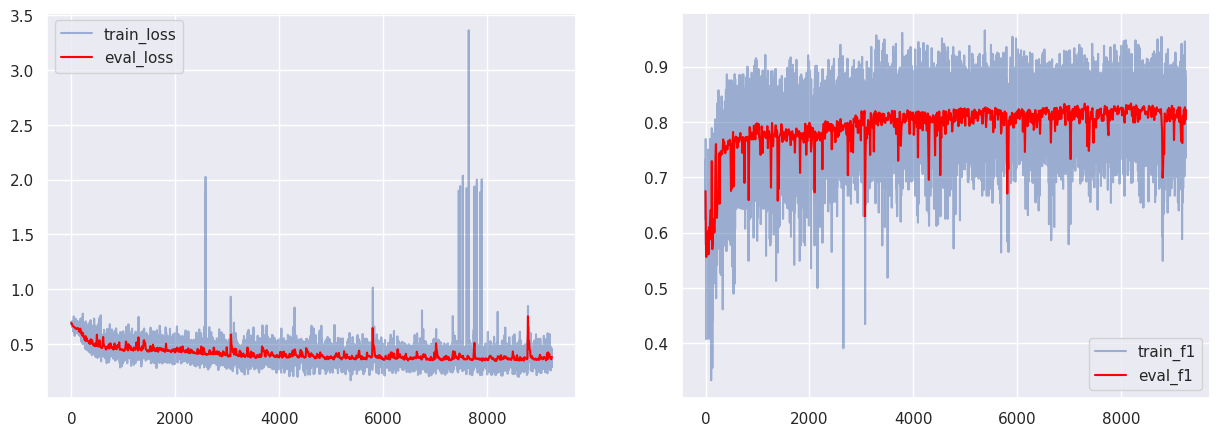

(0.3830031614303589, 0.8112449799196787)

In [21]:
set_seed(42)
model = MyTorchModel(1, 15, 15, 3, nn.LeakyReLU)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Уже лучше. Попробуем ещё

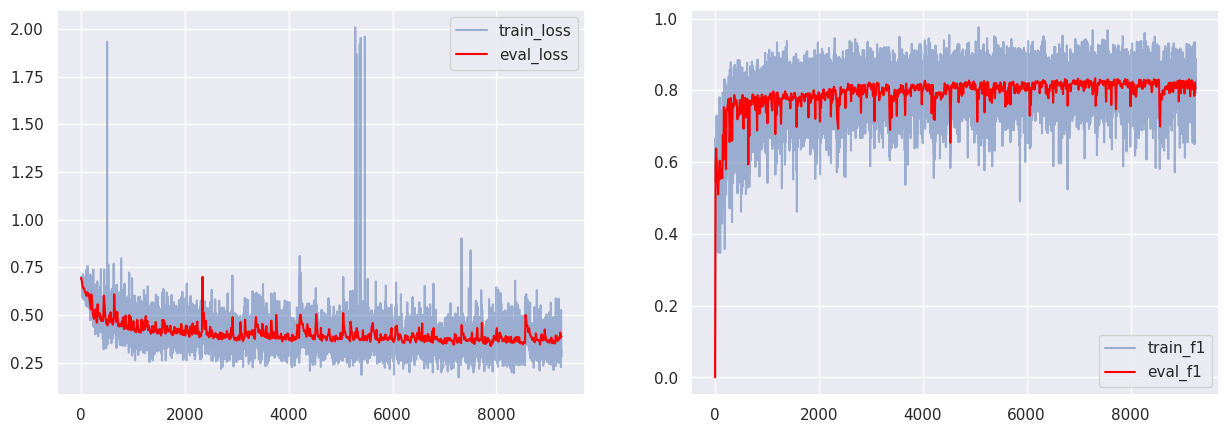

(0.36835756301879885, 0.8119139547710976)

In [22]:
set_seed(42)
model = MyTorchModel(1, 15, 15, 4, nn.LeakyReLU)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

f1-score чуть упал, попробуем 5 слоев

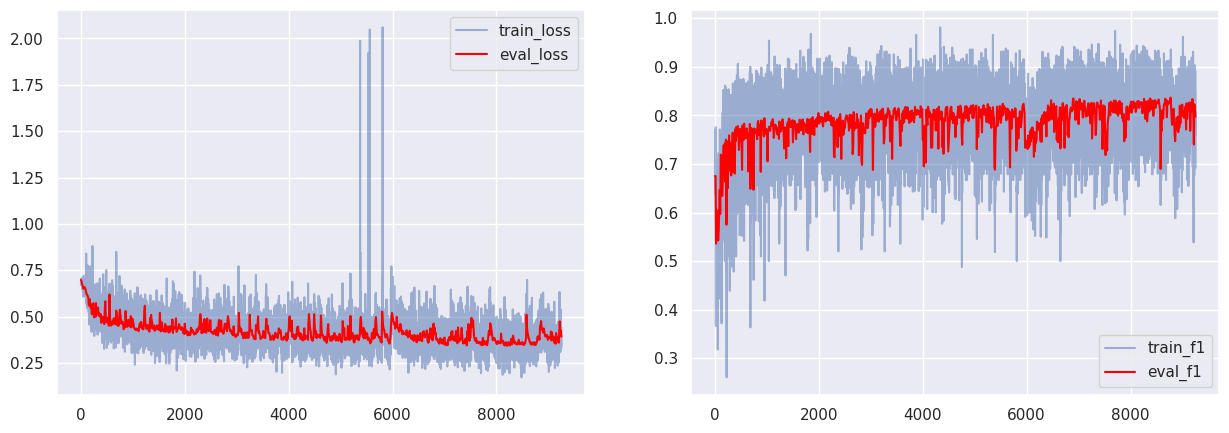

(0.3673104059696197, 0.7984453081621321)

In [23]:
set_seed(42)
model = MyTorchModel(1, 15, 15, 5, nn.LeakyReLU)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

# Стало хуже, поэтому остановимся на 3 слоях.

### Теперь заново обучим лучшую модель

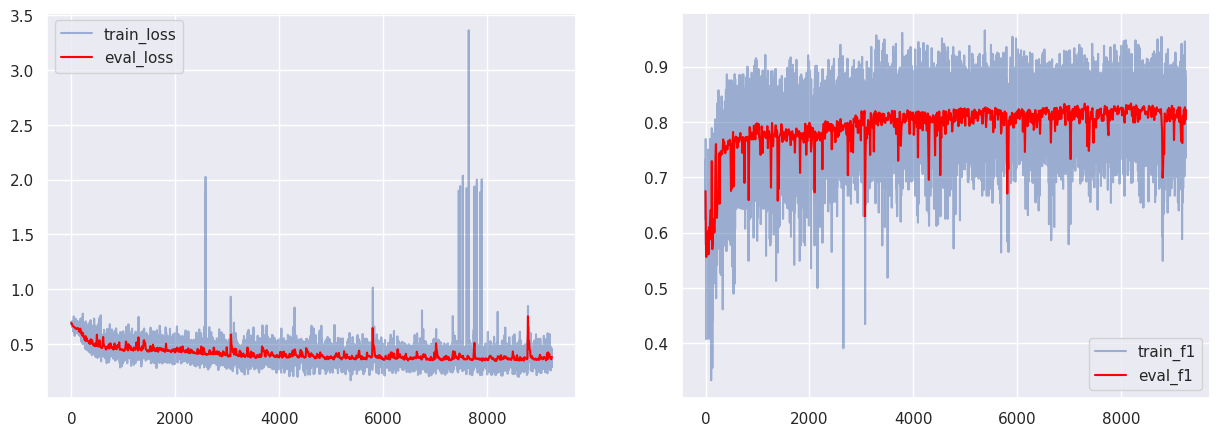

(0.3830031614303589, 0.8112449799196787)

In [24]:
set_seed(42)
model = MyTorchModel(1, 15, 15, 3, nn.LeakyReLU)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

In [25]:
model.eval()

preds_list = []
targets_list = []

with torch.no_grad():


    for batch_X, target in test_dataloader:
      y_prob = model(batch_X.to(device))
      y_pred_class = (y_prob >= 0.5).float()

      preds_list.extend(y_pred_class.cpu().numpy())
      targets_list.extend(target.numpy())

print(classification_report(targets_list, preds_list))

              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81       981
         1.0       0.83      0.79      0.81      1019

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000



# BatchNormalization и DropOut

Посмотрим как влияет на качество добавления BatchNormalization

In [26]:
class TheBestTorchModel(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU):
        super(TheBestTorchModel, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred


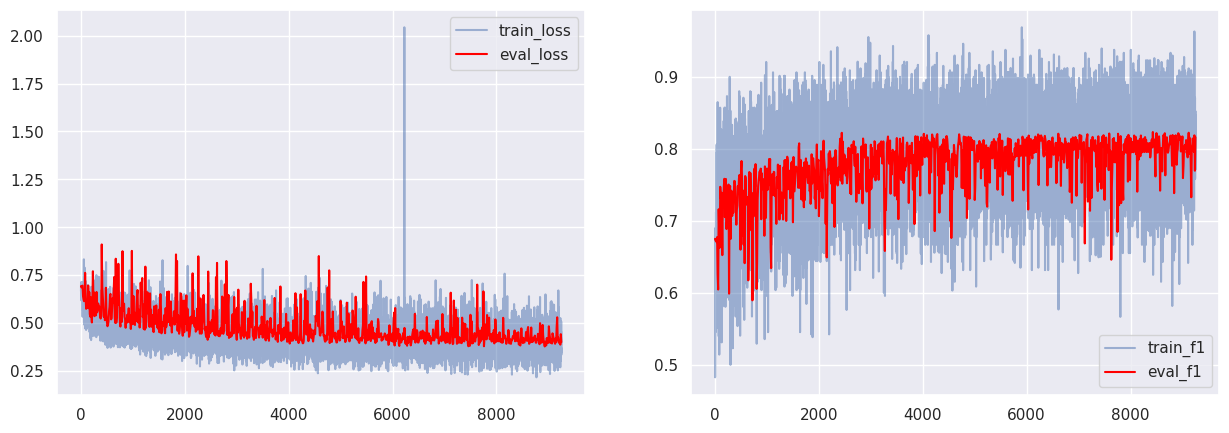

(0.38603228282928465, 0.8164493480441324)

In [27]:
set_seed(42)
model = TheBestTorchModel(1, 15, 15, 3, nn.LeakyReLU)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Стало хуже. Попробуем вместе в DropOut. Вероятность зануления возьмем не очень больщую = 0.2

In [28]:
class TheBestTorchModel2(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU, p=0.2):
        super(TheBestTorchModel2, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(p))
            layers.append(activation())

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred


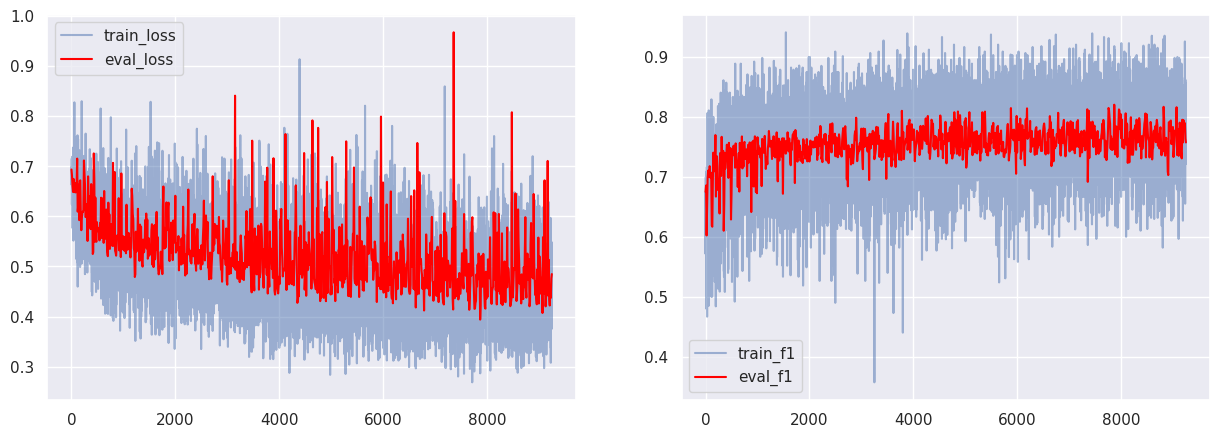

(0.4494393491744995, 0.7779215178956447)

In [29]:
set_seed(42)
model = TheBestTorchModel2(1, 15, 15, 3, nn.LeakyReLU, p=0.2)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Тоже не помогло. Попробуем применить DropOut после функции активации

In [30]:
class TheBestTorchModel3(nn.Module):
    def __init__(self, num_labels, input_size, hidden_size, n_linear_layers=3, activation=nn.ReLU, p=0.2):
        super(TheBestTorchModel3, self).__init__()

        layers = [nn.Linear(input_size, hidden_size), nn.BatchNorm1d(hidden_size), activation()]

        for i in range(n_linear_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(activation())
            layers.append(nn.Dropout(p))

        layers.append(nn.Linear(hidden_size, num_labels))
        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        y_pred = torch.sigmoid(self.layers(x))
        return y_pred


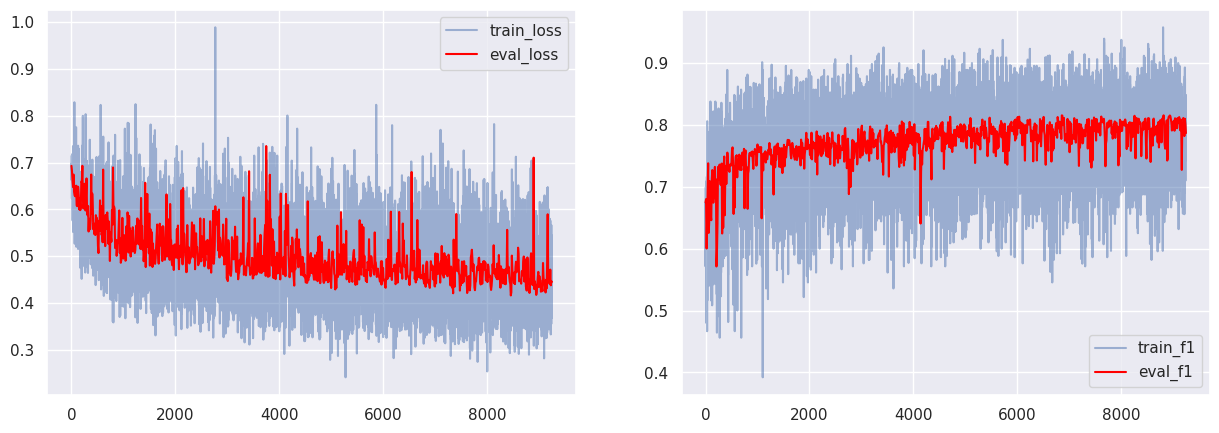

(0.4802104949951172, 0.7307898979043524)

In [31]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 15, 3, nn.LeakyReLU, p=0.2)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Стало хуже. Попробуем найти опитмальную вероятность для DropOut

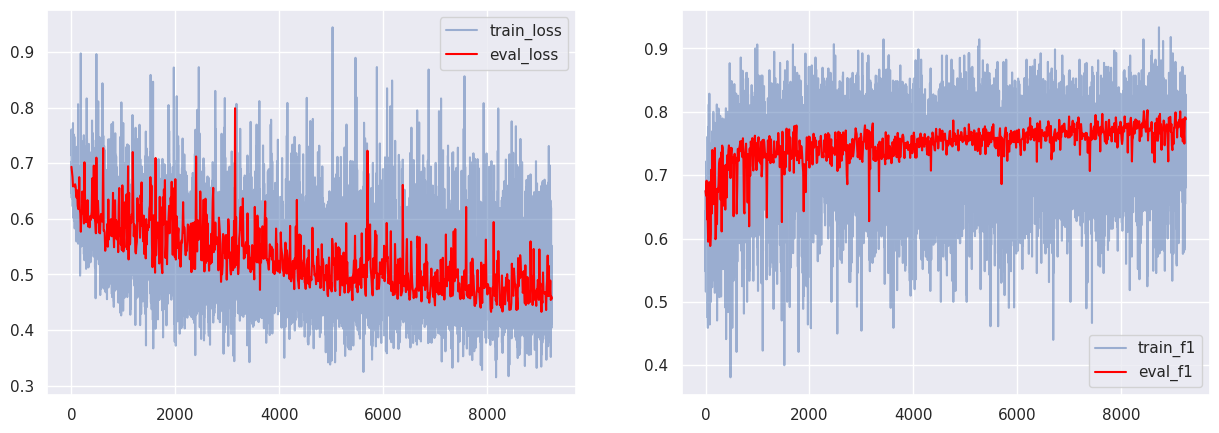

(0.4420650992393494, 0.7772795216741405)

In [32]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 15, 3, nn.LeakyReLU, p=0.4)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Не помогло

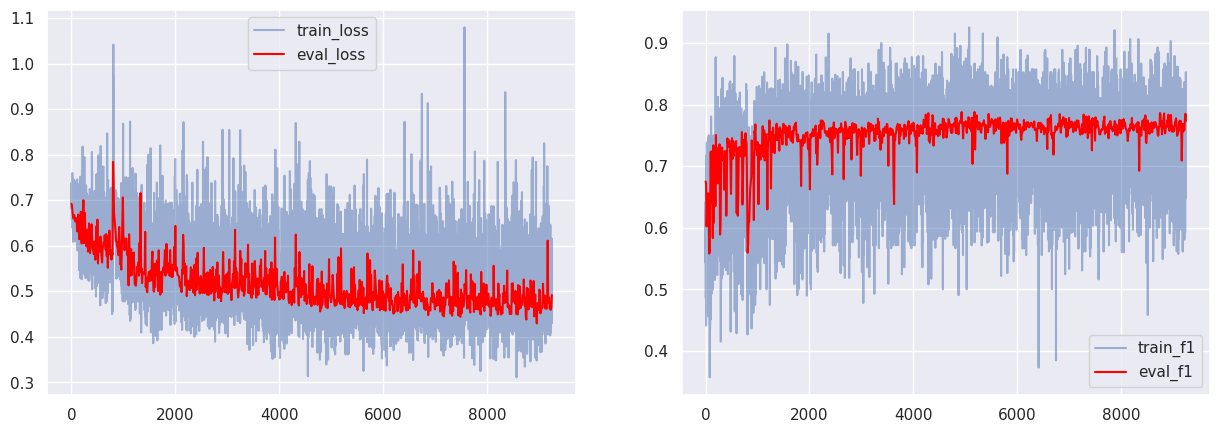

(0.45558575439453125, 0.7906482465462275)

In [33]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 15, 3, nn.LeakyReLU, p=0.5)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.01)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Не помогло. Попробуем уменьшить шаг обучения

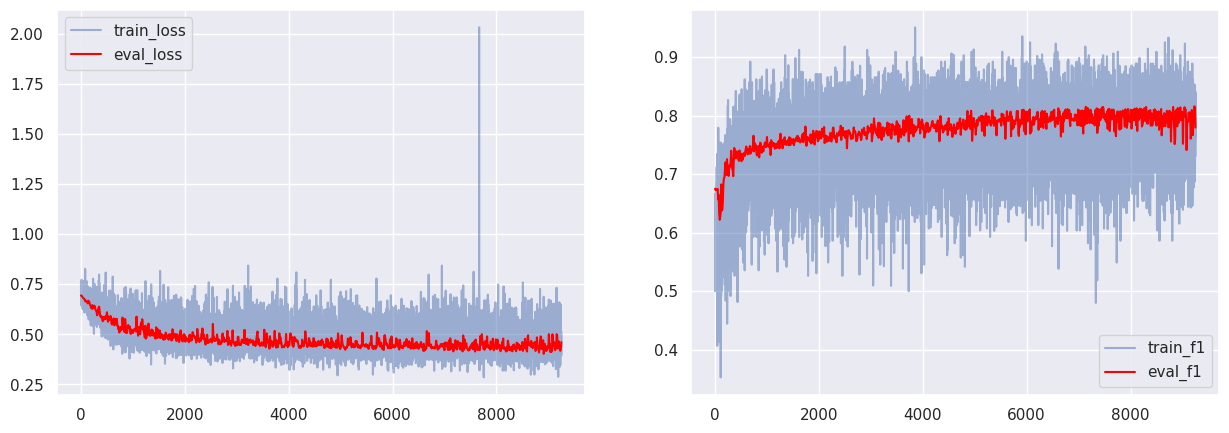

(0.42919350051879884, 0.8041035661944309)

In [34]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 15, 3, nn.LeakyReLU, p=0.4)
model.to(device)


optimizer = optim.Adam(model.parameters(), lr=0.001)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Не помогло. Попробуем использовать оптимизатор AdamW

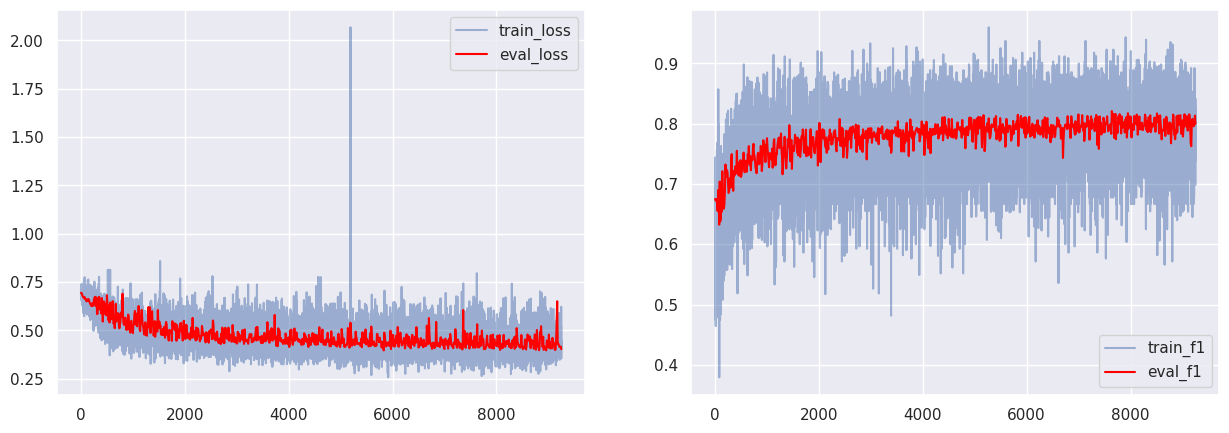

(0.4079168725013733, 0.7967323402210476)

In [35]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 15, 3, nn.LeakyReLU, p=0.2)
model.to(device)


optimizer = optim.AdamW(model.parameters(), lr=0.001)


model = train_model(model, num_epochs=100)


evaluate(model, data_loader=test_dataloader)

Не помогло( Может быть не хватает кол-ва эпох.

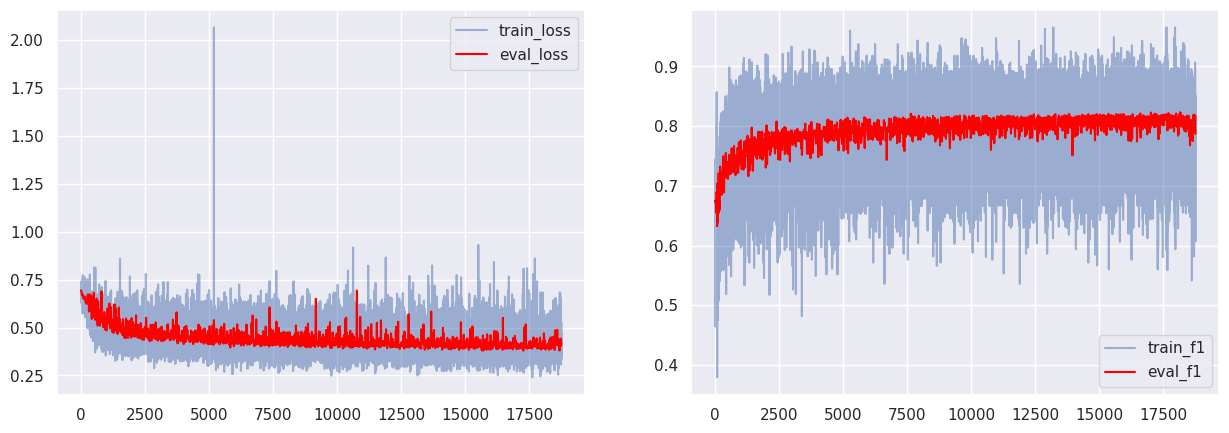

(0.40588062357902527, 0.8062166100048568)

In [36]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 15, 3, nn.LeakyReLU, p=0.2)
model.to(device)


optimizer = optim.AdamW(model.parameters(), lr=0.001)


model = train_model(model, num_epochs=200)


evaluate(model, data_loader=test_dataloader)

Не помогло. Попробуем расширить скрытые слои

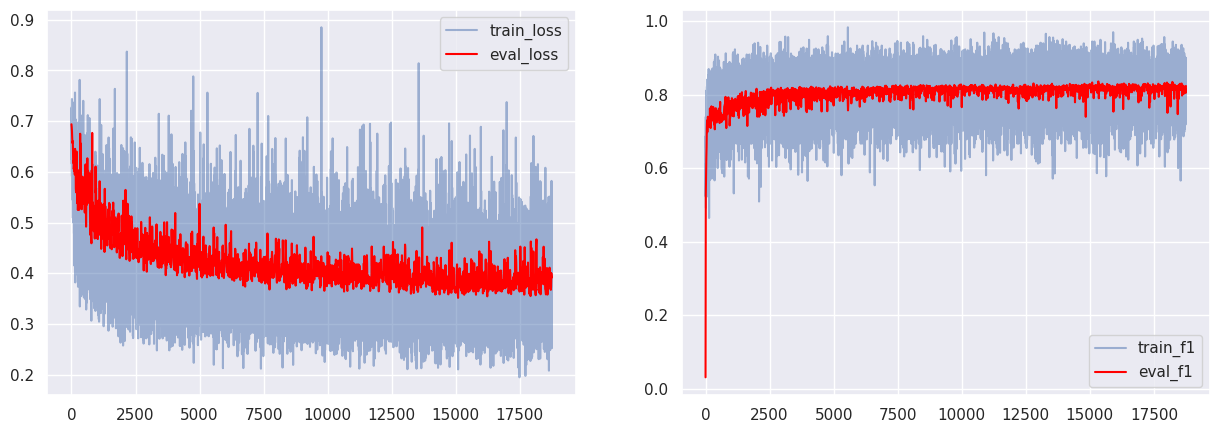

(0.365699695110321, 0.826530612244898)

In [37]:
set_seed(42)
model = TheBestTorchModel3(1, 15, 64, 3, nn.LeakyReLU, p=0.2)
model.to(device)


optimizer = optim.AdamW(model.parameters(), lr=0.001)


model = train_model(model, num_epochs=200)


evaluate(model, data_loader=test_dataloader)

УРААА! Наконец-то получилось получить модель, которая лучше, чем модель без BatchNormalization и DropOut

In [38]:
model.eval()

preds_list = []
targets_list = []

with torch.no_grad():


    for batch_X, target in test_dataloader:
      y_prob = model(batch_X.to(device))
      y_pred_class = (y_prob >= 0.5).float()

      preds_list.extend(y_pred_class.cpu().numpy())
      targets_list.extend(target.numpy())

print(classification_report(targets_list, preds_list))

              precision    recall  f1-score   support

         0.0       0.80      0.87      0.83       981
         1.0       0.86      0.79      0.83      1019

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



Выводы:

Архитектура: Эксперименты показали, что простое увеличение глубины сети (числа слоев) не дало прироста качества и даже ухудшило сходимость. Однако увеличение ширины слоев (hidden_size с 15 до 64) стало ключевым фактором успеха.

Регуляризация:

BatchNorm сам по себе не дал улучшения, но стабилизировал обучение.

Dropout: Оптимальное значение вероятности p=0.2. При p=0.4 модель недообучалась (underfitting).

Лучшая комбинация: Linear -> BatchNorm -> Activation -> Dropout.

Обучение: Переход на AdamW и понижение lr до 0.001 и увеличение кол-ва эпох до 200 позволили достичь плавного уменьшения Loss и максимальной F1-меры.